# VaR and ES Estimation

The goal in this notebook is to estimate two rolling risk measures of the portfolio:
1. **p% Value at Risk (VaR)** : the threshold where p% of the loss doesn't exceed
2. **p% Expected Shortfall (ES)** : the mean of extreme losses which exceed the p% VaR

We try the follwing methods:

- Historical Simulation (HS)
- Parametric Gaussian
- Parametric Student's T
- Filtered HS
- Filtered PG
- Filtered PST

In [1]:
import numpy as np
import pandas as pd
import pickle
import scipy.stats as stats
from matplotlib import pyplot as plt

import sys
sys.path.append("../src")
from risklib.plot_utils import shade_regimes

In [2]:
# Load portfolio return data
port_returns = pd.read_csv("../data/returns.csv", parse_dates=[0], index_col=0)[['Portfolio']]
port_loss = -port_returns
# Load estimated volatility and fitted volatility models
port_roll_garch_vol = pd.read_csv("../outputs/roll_garch_vol.csv", parse_dates=[0], index_col=0)[['Portfolio']]
port_roll_garch_mean = pd.read_csv("../outputs/roll_garch_mean.csv", parse_dates=[0], index_col=0)[['Portfolio']]
with open("../outputs/roll_garch_res.pkl", 'rb') as f:
    roll_garch_res = pickle.load(f)


### 1. Historical Simulation

In [8]:
# Estimate VaR/ES using HS
def get_var_es_HS(loss_win, q):
    var_dict = {}
    es_dict = {}
    for col in loss_win.columns:
        data = loss_win[col]
        var = np.quantile(data, q)
        es = data[data >= var].mean()
        var_dict[col], es_dict[col] = var, es
    return var_dict, es_dict

# Rolling estimation
def roll_var_es_HS(loss_df, window=504, q=0.99):
    columns = loss_df.columns
    var_HS = {col: [np.nan]*len(loss_df) for col in columns}
    es_HS = {col: [np.nan]*len(loss_df) for col in columns}
    for i in range(window, len(loss_df)):
        loss_win = loss_df[i-window:i]
        var_dict, es_dict = get_var_es_HS(loss_win, q)
        for col in columns:
            var_HS[col][i] = var_dict[col]
            es_HS[col][i] = es_dict[col]

    var_HS = pd.DataFrame(var_HS, index=loss_df.index)
    es_HS = pd.DataFrame(es_HS, index=loss_df.index)
    return var_HS, es_HS

port_var99_HS, port_es99_HS = roll_var_es_HS(port_loss, window=504, q=0.99)
port_var95_HS, port_es95_HS = roll_var_es_HS(port_loss, window=504, q=0.95)

### 2. Parametric - Gaussian

We assume losses in the estimation window follows a Gaussian distribution, then estimate VaR and ES by measuring analytical tails of the fitted Gaussian.

In [9]:
def get_var_es_PG(loss_win, q):
    var_dict, es_dict = {}, {}
    for col in loss_win.columns:
        data = loss_win[col]
        mu, std = stats.norm.fit(data)
        var_dict[col] = stats.norm.ppf(q=q, loc=mu, scale=std)
        es_dict[col] = mu + std*(stats.norm.pdf(stats.norm.ppf(q)) / (1-q))
    return var_dict, es_dict

# Rolling estimation
def roll_var_es_PG(loss_df, window=504, q=0.99):
    columns = loss_df.columns
    var_PG = {col: [np.nan]*len(loss_df) for col in columns}
    es_PG = {col: [np.nan]*len(loss_df) for col in columns}
    for i in range(window, len(loss_df)):
        loss_win = loss_df[i-window:i]
        var_dict, es_dict = get_var_es_PG(loss_win, q)
        for col in columns:
            var_PG[col][i] = var_dict[col]
            es_PG[col][i] = es_dict[col]

    var_PG = pd.DataFrame(var_PG, index=loss_df.index)
    es_PG = pd.DataFrame(es_PG, index=loss_df.index)
    return var_PG, es_PG

port_var99_PG, port_es99_PG = roll_var_es_PG(port_loss, window=504, q=0.99)
port_var95_PG, port_es95_PG = roll_var_es_PG(port_loss, window=504, q=0.95)

### 3. Parametric - Student's t

In [10]:
def get_var_es_PST(loss_win, q):
    var_dict, es_dict = {}, {}
    for col in loss_win.columns:
        data = loss_win[col]
        df, mu, std = stats.t.fit(data)   # df: degree of freedom
        var_dict[col] = stats.t.ppf(q=q, df=df, loc=mu, scale=std)
        es_dict[col] = -mu + std * (stats.t.pdf(stats.t.ppf(q,df=df),df=df) / (1-q)) * ((df + stats.t.ppf(q,df=df)**2) / (df-1))
    return var_dict, es_dict

# Rolling estimation
def roll_var_es_PST(loss_df, window=504, q=0.99):
    columns = loss_df.columns
    var_PST = {col: [np.nan]*len(loss_df) for col in columns}
    es_PST = {col: [np.nan]*len(loss_df) for col in columns}
    for i in range(window, len(loss_df)):
        loss_win = loss_df[i-window:i]
        var_dict, es_dict = get_var_es_PST(loss_win, q)
        for col in columns:
            var_PST[col][i] = var_dict[col]
            es_PST[col][i] = es_dict[col]
        if (i-window)%100 == 0:
            print(f"window {i-window} estimation complete")

    var_PST = pd.DataFrame(var_PST, index=loss_df.index)
    es_PST = pd.DataFrame(es_PST, index=loss_df.index)
    return var_PST, es_PST

port_var99_PST, port_es99_PST = roll_var_es_PST(port_loss, window=504, q=0.99)
port_var95_PST, port_es95_PST = roll_var_es_PST(port_loss, window=504, q=0.95)

window 0 estimation complete
window 100 estimation complete
window 200 estimation complete
window 300 estimation complete
window 400 estimation complete
window 500 estimation complete
window 600 estimation complete
window 700 estimation complete
window 800 estimation complete
window 900 estimation complete
window 1000 estimation complete
window 1100 estimation complete
window 1200 estimation complete
window 1300 estimation complete
window 1400 estimation complete
window 1500 estimation complete
window 1600 estimation complete
window 1700 estimation complete
window 1800 estimation complete
window 1900 estimation complete
window 2000 estimation complete
window 2100 estimation complete
window 2200 estimation complete
window 2300 estimation complete
window 2400 estimation complete
window 2500 estimation complete
window 2600 estimation complete
window 2700 estimation complete
window 2800 estimation complete
window 2900 estimation complete
window 3000 estimation complete
window 3100 estimati

### 4. Filtered Historical Simulation

Apart from regular historical simulation, which uses raw loss to estimate rolling VaR, we eliminate the volatility clustering in the loss series using volatility modeling from the previous notebook then use the standardized residuals to perform HS.

In [11]:
def get_var_es_FHS(garch_res, target_columns, vol, mean, q):
    """ Filtered Historical Simulation
    """
    var_dict, es_dict = {}, {}
    for col in target_columns:
        loss_resid = -garch_res[col].std_resid  
        resid_var = np.quantile(loss_resid, q)
        resid_es = loss_resid[loss_resid >= resid_var].mean()
        # Rescale using one-day ahead forecasts of the fitted volatility model
        var = resid_var * vol[col] + mean[col]
        es = resid_es * vol[col] + mean[col]
        var_dict[col], es_dict[col] = var, es
    return var_dict, es_dict

# Rolling estimation
def roll_var_es_FHS(roll_garch_res, target_columns, roll_garch_vol, roll_garch_mean, window=504, q=0.99):
    var_FHS = {col: [np.nan]*len(roll_garch_res) for col in target_columns}
    es_FHS = {col: [np.nan]*len(roll_garch_res) for col in target_columns}
    for i in range(window, len(roll_garch_res)):
        garch_res = roll_garch_res[i]
        fore_vol, fore_mean = roll_garch_vol.iloc[i], -roll_garch_mean.iloc[i]    # add negative sign since we are calculating loss
        var_dict, es_dict = get_var_es_FHS(garch_res, target_columns, fore_vol, fore_mean, q=q)
        for col in target_columns:
            var_FHS[col][i] = var_dict[col]
            es_FHS[col][i] = es_dict[col]

    var_FHS = pd.DataFrame(var_FHS, index=roll_garch_vol.index)
    es_FHS = pd.DataFrame(es_FHS, index=roll_garch_vol.index)
    return var_FHS, es_FHS

port_var99_FHS, port_es99_FHS = roll_var_es_FHS(
    roll_garch_res, ['Portfolio'], port_roll_garch_vol, port_roll_garch_mean, window=504, q=0.99
)
port_var95_FHS, port_es95_FHS = roll_var_es_FHS(
    roll_garch_res, ['Portfolio'], port_roll_garch_vol, port_roll_garch_mean, window=504, q=0.95
)

### 5. Filtered Parametric Student's t

In [12]:
def get_var_es_FPST(garch_res, target_columns, vol, mean, q):
    """ Filtered Historical Simulation
    """
    var_dict, es_dict = {}, {}
    for col in target_columns:
        loss_resid = -garch_res[col].std_resid
        df, mu, std = stats.t.fit(loss_resid)   # df: degree of freedom
        resid_var = stats.t.ppf(q=q, df=df, loc=mu, scale=std)
        resid_es = -mu + std * (stats.t.pdf(stats.t.ppf(q,df=df),df=df) / (1-q)) * ((df + stats.t.ppf(q,df=df)**2) / (df-1))
        # Rescale using one-day ahead forecasts of the fitted volatility model
        var = resid_var * vol[col] + mean[col]
        es = resid_es * vol[col] + mean[col]
        var_dict[col], es_dict[col] = var, es
    return var_dict, es_dict

# Rolling estimation
def roll_var_es_FPST(roll_garch_res, target_columns, roll_garch_vol, roll_garch_mean, window=504, q=0.99):
    var_FPST = {col: [np.nan]*len(roll_garch_res) for col in target_columns}
    es_FPST = {col: [np.nan]*len(roll_garch_res) for col in target_columns}
    for i in range(window, len(roll_garch_res)):
        garch_res = roll_garch_res[i]
        fore_vol, fore_mean = roll_garch_vol.iloc[i], -roll_garch_mean.iloc[i]    # add negative sign since we are calculating loss
        var_dict, es_dict = get_var_es_FPST(garch_res, target_columns, fore_vol, fore_mean, q=q)
        for col in target_columns:
            var_FPST[col][i] = var_dict[col]
            es_FPST[col][i] = es_dict[col]
        if (i-window) % 100 == 0:
            print(f"window {i-window} estimation complete")

    var_FPST = pd.DataFrame(var_FPST, index=roll_garch_vol.index)
    es_FPST = pd.DataFrame(es_FPST, index=roll_garch_vol.index)
    return var_FPST, es_FPST

port_var99_FPST, port_es99_FPST = roll_var_es_FPST(
    roll_garch_res, ['Portfolio'], port_roll_garch_vol, port_roll_garch_mean, window=504, q=0.99
)
port_var95_FPST, port_es95_FPST = roll_var_es_FPST(
    roll_garch_res, ['Portfolio'], port_roll_garch_vol, port_roll_garch_mean, window=504, q=0.95
)

window 0 estimation complete
window 100 estimation complete
window 200 estimation complete
window 300 estimation complete
window 400 estimation complete
window 500 estimation complete
window 600 estimation complete
window 700 estimation complete
window 800 estimation complete
window 900 estimation complete
window 1000 estimation complete
window 1100 estimation complete
window 1200 estimation complete
window 1300 estimation complete
window 1400 estimation complete
window 1500 estimation complete
window 1600 estimation complete
window 1700 estimation complete
window 1800 estimation complete
window 1900 estimation complete
window 2000 estimation complete
window 2100 estimation complete
window 2200 estimation complete
window 2300 estimation complete
window 2400 estimation complete
window 2500 estimation complete
window 2600 estimation complete
window 2700 estimation complete
window 2800 estimation complete
window 2900 estimation complete
window 3000 estimation complete
window 3100 estimati

### Comparison

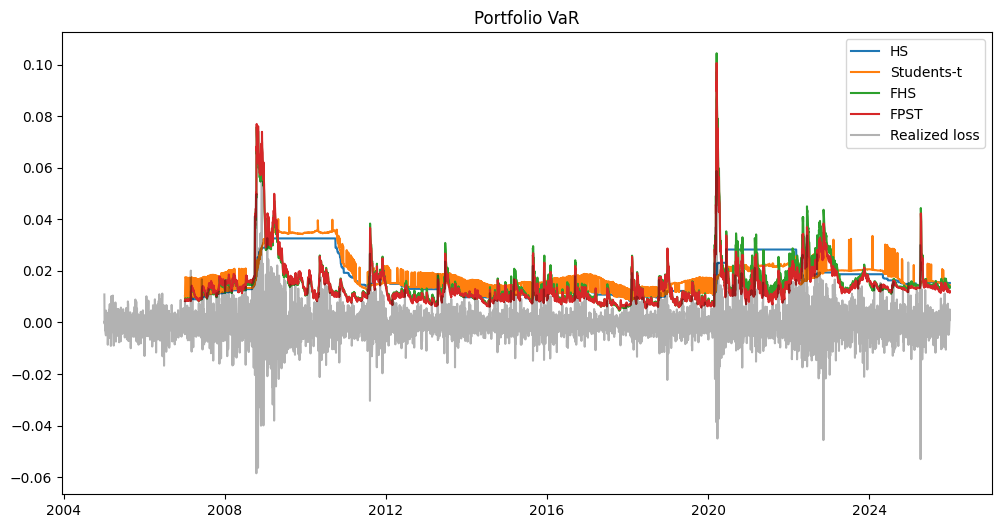

In [13]:
# Plot Portfolio rolling VaR estimated with different models
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(port_var99_HS, label="HS")
#ax.plot(port_var99_PG, label="Gaussian")
ax.plot(port_var99_PST, label="Students-t")
ax.plot(port_var99_FHS, label="FHS")
ax.plot(port_var99_FPST, label="FPST")
ax.plot(port_loss, label="Realized loss", color='black', alpha=0.3)
ax.legend()
ax.set_title("Portfolio VaR")
plt.show()

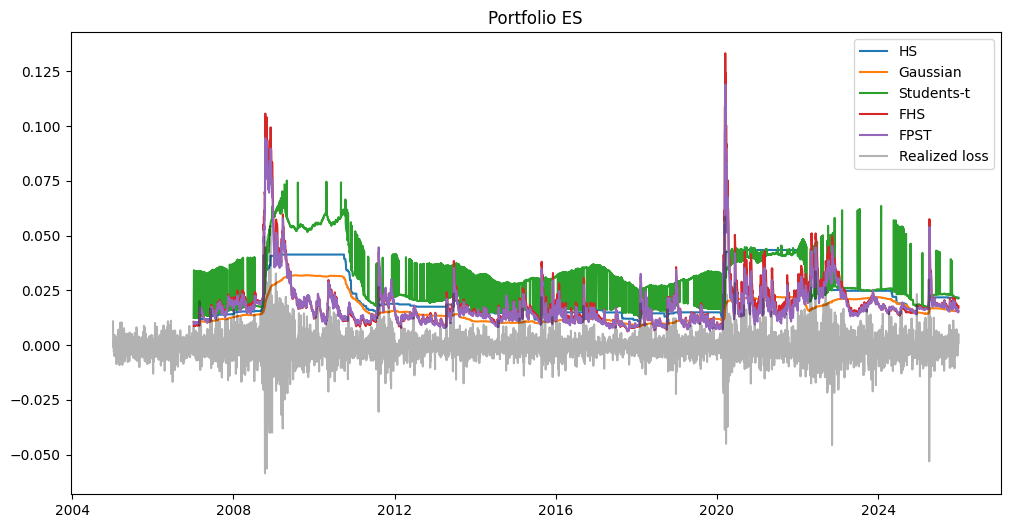

In [14]:
# Plot Portfolio rolling ES estimated using different models 
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(port_es99_HS, label="HS")
ax.plot(port_es99_PG, label="Gaussian")
ax.plot(port_es99_PST, label="Students-t")
ax.plot(port_es99_FHS, label="FHS")
ax.plot(port_es99_FPST, label="FPST")
ax.plot(port_loss, label="Realized loss", color='black', alpha=0.3)
ax.legend()
ax.set_title("Portfolio ES")
plt.show()

## Save outputs

In [15]:
# Save to ../outputs
var_models = ['HS','PG','PST','FHS','FPST']

port_var99 = pd.concat([port_var99_HS, port_var99_PG, port_var99_PST, port_var99_FHS, port_var99_FPST], axis=1)
port_var99.columns = var_models
port_var99.to_csv("../outputs/port_var99.csv")

port_es99 = pd.concat([port_es99_HS, port_es99_PG, port_es99_PST, port_es99_FHS, port_es99_FPST], axis=1)
port_es99.columns = var_models
port_es99.to_csv("../outputs/port_es99.csv")

port_var95 = pd.concat([port_var95_HS, port_var95_PG, port_var95_PST, port_var95_FHS, port_var95_FPST], axis=1)
port_var95.columns = var_models
port_var95.to_csv("../outputs/port_var95.csv")

port_es95 = pd.concat([port_es95_HS, port_es95_PG, port_es95_PST, port_es95_FHS, port_es95_FPST], axis=1)
port_es95.columns = var_models
port_es95.to_csv("../outputs/port_es95.csv")